**Clustering**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [4]:
milk = pd.read_csv('../datasets/milk.csv',index_col=0)
milk

,water,protein,fat,lactose,ash
Animal,,,,,
HORSE,90.1,2.6,1.0,6.9,0.35
ORANGUTAN,88.5,1.4,3.5,6.0,0.24
MONKEY,88.4,2.2,2.7,6.4,0.18
DONKEY,90.3,1.7,1.4,6.2,0.40
HIPPO,90.4,0.6,4.5,4.4,0.10
CAMEL,87.7,3.5,3.4,4.8,0.71
BISON,86.9,4.8,1.7,5.7,0.90
BUFFALO,82.1,5.9,7.9,4.7,0.78
GUINEA PIG,81.9,7.4,7.2,2.7,0.85


In [5]:
scaler = StandardScaler().set_output(transform='pandas')
milk_scaled = scaler.fit_transform(milk)

#Scaled values
milk_scaled

,water,protein,fat,lactose,ash
Animal,,,,,
HORSE,0.948806,-1.009291,-0.903208,1.542217,-1.037554
ORANGUTAN,0.821407,-1.344603,-0.660619,1.040773,-1.259945
MONKEY,0.813445,-1.121062,-0.738247,1.263637,-1.381249
DONKEY,0.964731,-1.260775,-0.864394,1.152205,-0.936467
HIPPO,0.972694,-1.568145,-0.563583,0.149319,-1.542988
CAMEL,0.757707,-0.757806,-0.670322,0.372182,-0.309730
BISON,0.694008,-0.394551,-0.835283,0.873626,0.074400
BUFFALO,0.311810,-0.087181,-0.233662,0.316466,-0.168208
GUINEA PIG,0.295885,0.331959,-0.301587,-0.797852,-0.026687


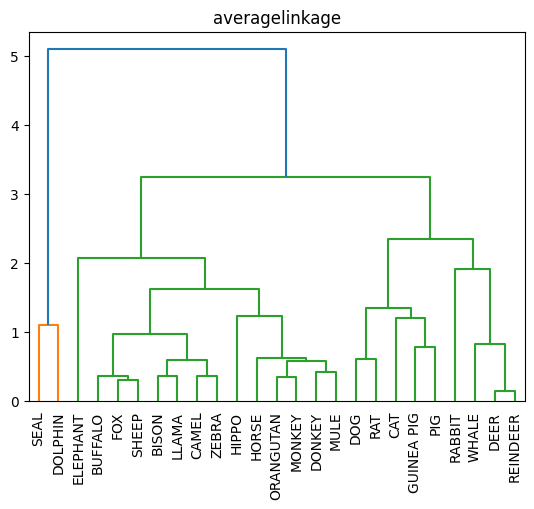

In [6]:
link = 'average'
mergings = linkage(milk_scaled, method=link)
dendrogram(mergings, labels=list(milk_scaled.index))
plt.title(link + 'linkage')
plt.xticks(rotation=90)
plt.show()

In [7]:
link  = 'average'
clust = AgglomerativeClustering(n_clusters=2, linkage=link)
clust.fit(milk_scaled)
labels = clust.labels_
sil_score = silhouette_score(milk_scaled, labels, metric='euclidean')
#metric='euclidean' 'manhattan', 'cosine', 'chebyshev', 'minkowski
print("Silhouette Coefficient:", sil_score)

Silhouette Coefficient: 0.5186847578981009


In [8]:
#For all linkage options: and range of clusters: 
linkages = ['average', 'ward', 'complete', 'single']
clusters = np.arange(2,9)
scores = []
for c in clusters:
    for link in linkages:
        clust = AgglomerativeClustering(n_clusters=c, linkage=link)
        clust.fit(milk_scaled)
        scores.append([link, c, silhouette_score(milk_scaled, labels=clust.labels_)])


df_scores = pd.DataFrame(scores, columns=['linkage', 'clusters', 'score' ])
df_scores.sort_values('score', ascending=False )


,linkage,clusters,score
5,ward,3,0.539160
1,ward,2,0.525851
3,single,2,0.518685
0,average,2,0.518685
6,complete,3,0.487576
4,average,3,0.487576
2,complete,2,0.455789
9,ward,4,0.443481
18,complete,6,0.419614
10,complete,4,0.416015


Using PCA

In [9]:
scaler = StandardScaler().set_output(transform='pandas')
milk_scaled = scaler.fit_transform(milk)

#Scaled values
milk_scaled

,water,protein,fat,lactose,ash
Animal,,,,,
HORSE,0.948806,-1.009291,-0.903208,1.542217,-1.037554
ORANGUTAN,0.821407,-1.344603,-0.660619,1.040773,-1.259945
MONKEY,0.813445,-1.121062,-0.738247,1.263637,-1.381249
DONKEY,0.964731,-1.260775,-0.864394,1.152205,-0.936467
HIPPO,0.972694,-1.568145,-0.563583,0.149319,-1.542988
CAMEL,0.757707,-0.757806,-0.670322,0.372182,-0.309730
BISON,0.694008,-0.394551,-0.835283,0.873626,0.074400
BUFFALO,0.311810,-0.087181,-0.233662,0.316466,-0.168208
GUINEA PIG,0.295885,0.331959,-0.301587,-0.797852,-0.026687


In [10]:
prcomp = PCA().set_output(transform='pandas')
pca_data = prcomp.fit_transform(milk_scaled)

clust = AgglomerativeClustering(n_clusters=3, linkage='ward')
clust.fit(milk_scaled)

pca_data=pca_data.iloc[:,:2]
pca_data['Cluster'] = clust.labels_
pca_data['Cluster'] = pca_data['Cluster'].astype(str)

pca_data

,pca0,pca1,Cluster
Animal,,,
HORSE,2.435175,-0.231478,0
ORANGUTAN,2.258736,-0.693148,0
MONKEY,2.335861,-0.663328,0
DONKEY,2.318677,-0.273815,0
HIPPO,2.060294,-1.019199,0
CAMEL,1.301536,0.137303,0
BISON,1.282742,0.622667,0
BUFFALO,0.505068,0.088235,0
GUINEA PIG,-0.255502,0.287373,0


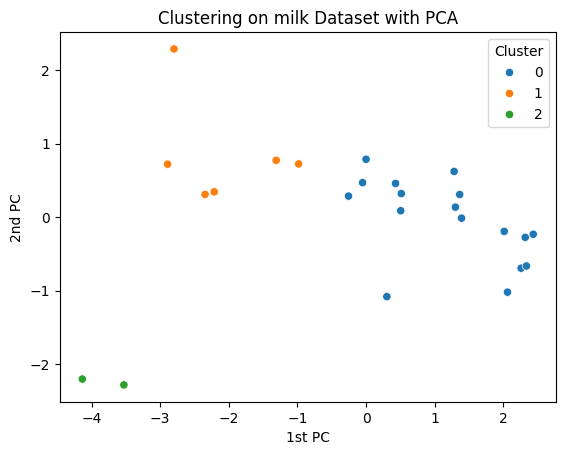

In [11]:
sns.scatterplot(data=pca_data, x='pca0', y='pca1', hue='Cluster')
plt.xlabel('1st PC')
plt.title('Clustering on milk Dataset with PCA')
plt.ylabel('2nd PC')
plt.show()

Nutrient

In [ ]:
nut = pd.read_csv('../datasets/nutrient.csv')
scaler = StandardScaler().set_output(transform = 'pandas')
df_scaled = 